In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load NYC 311 dataset directly from NYC Open Data
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=50000"
df = pd.read_csv(url)

# First look
print(df.shape)
print(df.dtypes)
df.head()

(50000, 44)
unique_key                          int64
created_date                       object
closed_date                        object
agency                             object
agency_name                        object
complaint_type                     object
descriptor                         object
descriptor_2                       object
location_type                      object
incident_zip                      float64
incident_address                   object
street_name                        object
cross_street_1                     object
cross_street_2                     object
intersection_street_1              object
intersection_street_2              object
address_type                       object
city                               object
landmark                           object
facility_type                      object
status                             object
due_date                           object
resolution_description             object
resolution_action_upda

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,69284094,2026-06-09T02:15:22.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11356.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.792711,-73.846534,POINT (-73.846533932819 40.792710620503)
1,69292844,2026-06-09T02:06:15.000,NaN,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,NaN,Street/Sidewalk,10457.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.846570,-73.908310,POINT (-73.908309924409 40.846570079096)
2,69294492,2026-06-09T02:06:02.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Talking,NaN,Residential Building/House,11235.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.581496,-73.965781,POINT (-73.965781496749 40.581496145029)
3,69292734,2026-06-09T02:04:16.000,NaN,TLC,Taxi and Limousine Commission,For Hire Vehicle Complaint,Driver Complaint - Non Passenger,Unsafe Driving,NaN,11207.0,...,NaN,NaN,"20 JACKIE ROBINSON PARKWAY, BROOKLYN, NY, 11207",NaN,NaN,NaN,NaN,40.681214,-73.896192,POINT (-73.896192261272 40.681213741226)
4,69294411,2026-06-09T02:03:20.000,NaN,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,NaN,Street/Sidewalk,10040.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.859783,-73.927036,POINT (-73.927036095807 40.859782723203)


In [2]:
# Step 2: Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                                Missing Count  Missing %
taxi_company_borough                    49978      99.96
facility_type                           49905      99.81
due_date                                49902      99.80
road_ramp                               49897      99.79
bridge_highway_direction                49892      99.78
bridge_highway_name                     49792      99.58
bridge_highway_segment                  49792      99.58
taxi_pick_up_location                   49480      98.96
vehicle_type                            47318      94.64
descriptor_2                            32493      64.99
closed_date                             16500      33.00
landmark                                15122      30.24
intersection_street_1                   11098      22.20
intersection_street_2                   11083      22.17
cross_street_1                           9104      18.21
cross_street_2                           9094      18.19
resolution_description         

In [3]:
# Step 3: Clean the data

# 3a. Drop columns that are mostly empty (over 90% missing)
cols_to_drop = missing_df[missing_df['Missing %'] > 90].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")

# 3b. Convert date columns to datetime
df_clean['created_date'] = pd.to_datetime(df_clean['created_date'])
df_clean['closed_date'] = pd.to_datetime(df_clean['closed_date'])

# 3c. Create a new column: resolution time in hours
df_clean['resolution_hours'] = (
    df_clean['closed_date'] - df_clean['created_date']
).dt.total_seconds() / 3600

# 3d. Drop duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after} duplicate rows")

# 3e. Standardize borough column to uppercase
df_clean['borough'] = df_clean['borough'].str.upper().str.strip()

# 3f. Final shape
print(f"\nClean dataset shape: {df_clean.shape}")
print(df_clean.dtypes)

Dropped 9 columns: ['taxi_company_borough', 'facility_type', 'due_date', 'road_ramp', 'bridge_highway_direction', 'bridge_highway_name', 'bridge_highway_segment', 'taxi_pick_up_location', 'vehicle_type']
Removed 0 duplicate rows

Clean dataset shape: (50000, 36)
unique_key                                 int64
created_date                      datetime64[ns]
closed_date                       datetime64[ns]
agency                                    object
agency_name                               object
complaint_type                            object
descriptor                                object
descriptor_2                              object
location_type                             object
incident_zip                             float64
incident_address                          object
street_name                               object
cross_street_1                            object
cross_street_2                            object
intersection_street_1                     object
in

In [4]:
# Step 4: Exploratory Data Analysis

# 4a. What are the most common complaint types?
print("=== TOP 10 COMPLAINT TYPES ===")
print(df_clean['complaint_type'].value_counts().head(10))

# 4b. Which borough has the most complaints?
print("\n=== COMPLAINTS BY BOROUGH ===")
print(df_clean['borough'].value_counts())

# 4c. What agencies handle the most complaints?
print("\n=== TOP 10 AGENCIES ===")
print(df_clean['agency_name'].value_counts().head(10))

# 4d. Resolution time stats (only closed complaints)
print("\n=== RESOLUTION TIME (hours) ===")
print(df_clean['resolution_hours'].describe())

# 4e. How are complaints submitted?
print("\n=== CHANNEL TYPE ===")
print(df_clean['open_data_channel_type'].value_counts())

=== TOP 10 COMPLAINT TYPES ===
complaint_type
Illegal Parking            8163
Noise - Residential        5751
Noise - Street/Sidewalk    3974
Damaged Tree               2928
Blocked Driveway           2469
Water System               1374
UNSANITARY CONDITION       1343
Street Condition           1287
Noise - Commercial         1150
Noise - Vehicle            1081
Name: count, dtype: int64

=== COMPLAINTS BY BOROUGH ===
borough
BROOKLYN         15282
QUEENS           14527
BRONX             9140
MANHATTAN         9048
STATEN ISLAND     1937
UNSPECIFIED         66
Name: count, dtype: int64

=== TOP 10 AGENCIES ===
agency_name
New York City Police Department                       25277
Department of Housing Preservation and Development     5920
Department of Parks and Recreation                     5268
Department of Sanitation                               3555
Department of Transportation                           3079
Department of Environmental Protection                 2895
Departme

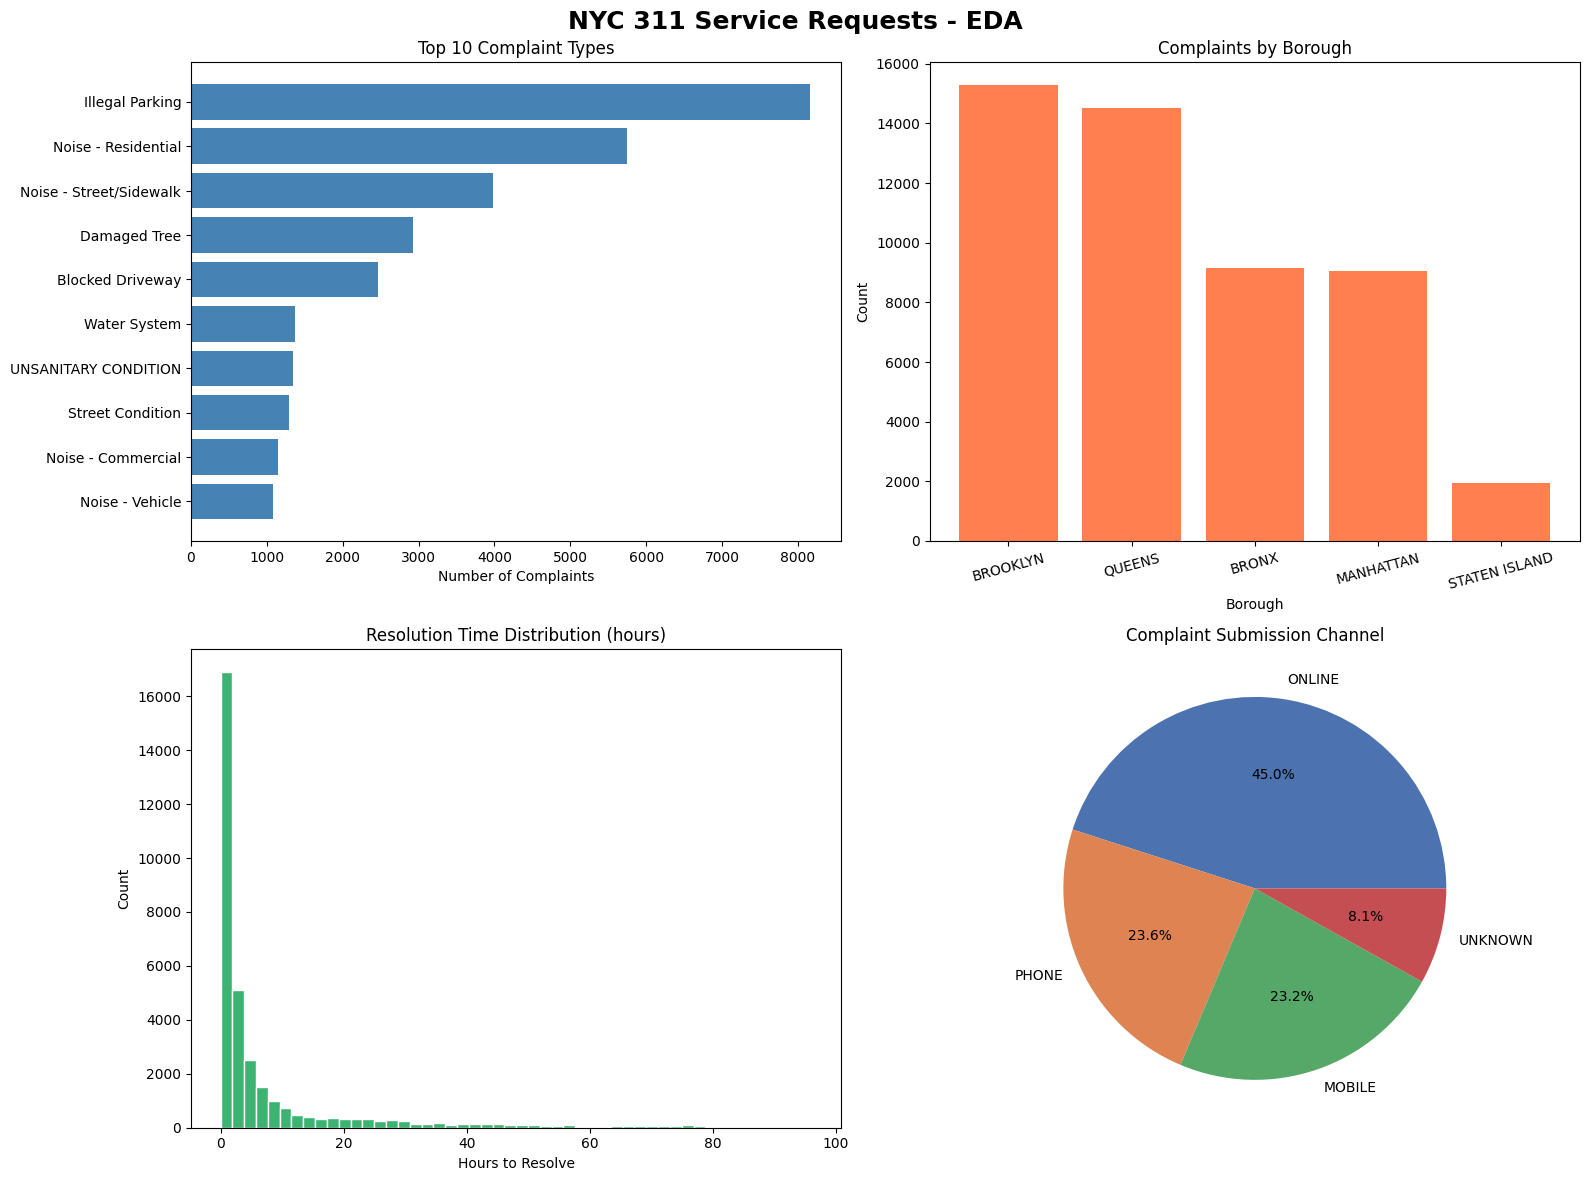

Chart saved!


In [5]:
# Step 5: Visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NYC 311 Service Requests - EDA', fontsize=18, fontweight='bold')

# Chart 1: Top 10 Complaint Types
top_complaints = df_clean['complaint_type'].value_counts().head(10)
axes[0, 0].barh(top_complaints.index[::-1], top_complaints.values[::-1], color='steelblue')
axes[0, 0].set_title('Top 10 Complaint Types')
axes[0, 0].set_xlabel('Number of Complaints')

# Chart 2: Complaints by Borough
borough_counts = df_clean['borough'].value_counts()
borough_counts = borough_counts[borough_counts.index != 'UNSPECIFIED']
axes[0, 1].bar(borough_counts.index, borough_counts.values, color='coral')
axes[0, 1].set_title('Complaints by Borough')
axes[0, 1].set_xlabel('Borough')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=15)

# Chart 3: Resolution Time Distribution (clean only)
valid_res = df_clean[(df_clean['resolution_hours'] >= 0) &
                      (df_clean['resolution_hours'] <= 104)]
axes[1, 0].hist(valid_res['resolution_hours'], bins=50, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Resolution Time Distribution (hours)')
axes[1, 0].set_xlabel('Hours to Resolve')
axes[1, 0].set_ylabel('Count')

# Chart 4: Submission Channel
channel_counts = df_clean['open_data_channel_type'].value_counts()
axes[1, 1].pie(channel_counts.values, labels=channel_counts.index,
               autopct='%1.1f%%', colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1, 1].set_title('Complaint Submission Channel')

plt.tight_layout()
plt.savefig('nyc_311_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
# Step 6: Key Findings Summary

summary = """
==============================================
NYC 311 SERVICE REQUESTS — KEY FINDINGS
Dataset: 50,000 most recent complaints
==============================================

1. ILLEGAL PARKING IS THE #1 COMPLAINT
   - 8,163 complaints (16.3% of all requests)
   - Nearly double the next complaint type (Noise - Residential at 5,751)

2. BROOKLYN & QUEENS DRIVE COMPLAINT VOLUME
   - Brooklyn: 15,282 | Queens: 14,527
   - Together they account for ~60% of all complaints
   - Staten Island is a distant last with only 1,937

3. NYPD HANDLES HALF OF ALL COMPLAINTS
   - 25,277 out of 50,000 requests routed to NYPD
   - Primarily driven by parking and noise complaints

4. MOST COMPLAINTS RESOLVE WITHIN 2 HOURS
   - Median resolution time: 1.88 hours
   - Mean is higher (7.7 hrs) due to outliers pulling it up
   - Negative resolution times detected (-72 hrs) — likely data entry errors

5. ONLINE IS THE DOMINANT SUBMISSION CHANNEL
   - 45% of complaints submitted online
   - Phone (23.6%) and Mobile (23.2%) are nearly equal
   - 8.1% flagged as UNKNOWN channel

==============================================
DATA QUALITY ISSUES FOUND & ADDRESSED
==============================================
- 9 columns dropped (>90% missing): taxi, bridge/highway, facility fields
- Dates converted from string to datetime
- Negative resolution times identified as anomalies
- Borough field standardized to uppercase
- No duplicate rows found
"""

print(summary)


NYC 311 SERVICE REQUESTS — KEY FINDINGS
Dataset: 50,000 most recent complaints

1. ILLEGAL PARKING IS THE #1 COMPLAINT
   - 8,163 complaints (16.3% of all requests)
   - Nearly double the next complaint type (Noise - Residential at 5,751)

2. BROOKLYN & QUEENS DRIVE COMPLAINT VOLUME
   - Brooklyn: 15,282 | Queens: 14,527
   - Together they account for ~60% of all complaints
   - Staten Island is a distant last with only 1,937

3. NYPD HANDLES HALF OF ALL COMPLAINTS
   - 25,277 out of 50,000 requests routed to NYPD
   - Primarily driven by parking and noise complaints

4. MOST COMPLAINTS RESOLVE WITHIN 2 HOURS
   - Median resolution time: 1.88 hours
   - Mean is higher (7.7 hrs) due to outliers pulling it up
   - Negative resolution times detected (-72 hrs) — likely data entry errors

5. ONLINE IS THE DOMINANT SUBMISSION CHANNEL
   - 45% of complaints submitted online
   - Phone (23.6%) and Mobile (23.2%) are nearly equal
   - 8.1% flagged as UNKNOWN channel

DATA QUALITY ISSUES FOUND 